# Snorkel Weak Labeling

**Objective:** Apply Snorkel labeling functions (LFs) to generate probabilistic weak labels  
for the full contract dataset.

| | |
|---|---|
| **Input** | Engineered dataset (`Data/processed/`) |
| **Output** | `Data/processed/contract_snorkel_labeled.csv` — with `renegotiation_prob` + `target_renegotiate` |
| **LF logic** | All LFs and helpers live in `src/master_thesis/snorkel_lfs.py` |

Labeling logic and LF definitions live in `snorkel_lfs.py`.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print(src_path)

/Users/Thomas/Desktop/Master Thesis/src


## 1  Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from snorkel.labeling import PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel

from master_thesis.config import DATA_RAW, DATA_PROCESSED, REPORTS, SEED
from master_thesis.snorkel_lfs import (
    ABSTAIN, NO, YES,
    prepare_snorkel_dataframe,
    LF_GROUPS,
    ALL_LFS,
)

print(f"Total LF groups : {len(LF_GROUPS)}")
print(f"Total LFs       : {len(ALL_LFS)}")

Total LF groups : 7
Total LFs       : 39


## 2  Load the engineered dataset

In [ ]:
df_raw = pd.read_csv(
    DATA_RAW / "contract_final_no_spend.csv",
    dtype={"terminated": "str", "supplier_number": "str"},
    low_memory=False,
)

print(f"Shape          : {df_raw.shape}")
print(f"Unique contracts: {df_raw['contract_id'].nunique()}")

Shape          : (9201, 149)
Unique contracts: 2209


## 3 · Prepare DataFrame for LF application

In [15]:
df_snorkel = prepare_snorkel_dataframe(df_raw)
print(f"Ready for LF application: {df_snorkel.shape}")

Ready for LF application: (9201, 152)


## 4  Apply LFs

In [5]:
applier = PandasLFApplier(lfs=ALL_LFS)
L = applier.apply(df=df_snorkel)

print("Label matrix shape:", L.shape)

  0%|          | 0/9201 [00:00<?, ?it/s]

100%|██████████| 9201/9201 [00:01<00:00, 6325.43it/s]

Label matrix shape: (9201, 39)


## 5  LF diagnostics

In [6]:
lf_summary = LFAnalysis(L=L, lfs=ALL_LFS).lf_summary()

# Map each LF back to its group
lf_group_map = {}
for group_name, lf_list in LF_GROUPS.items():
    for lf in lf_list:
        lf_group_map[lf.name] = group_name

lf_summary["group"] = lf_summary.index.map(lf_group_map)
lf_summary = lf_summary.reset_index().rename(columns={"index": "lf_name"})

display(
    lf_summary.sort_values(["group", "Coverage"], ascending=[True, False])
)

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/snorkel/labeling/analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


,lf_name,j,Polarity,Coverage,Overlaps,Conflicts,group
15,lf_global_esg_low_env_or_social,15,[1],0.061080,0.061080,0.001739,global_esg
14,lf_global_esg_low_industry_adjusted,14,[1],0.035648,0.035648,0.000869,global_esg
16,lf_global_esg_low_governance,16,[1],0.001956,0.001956,0.000000,global_esg
13,lf_global_esg_very_low_overall,13,[],0.000000,0.000000,0.000000,global_esg
5,lf_global_financial_severe_stress,5,[],0.000000,0.000000,0.000000,global_financial
6,lf_global_financial_multiple_stress,6,[],0.000000,0.000000,0.000000,global_financial
7,lf_global_financial_rating_weak,7,[],0.000000,0.000000,0.000000,global_financial
8,lf_global_financial_do_not_source,8,[],0.000000,0.000000,0.000000,global_financial
9,lf_global_financial_liquidity_stress,9,[],0.000000,0.000000,0.000000,global_financial
10,lf_global_financial_profitability_stress,10,[],0.000000,0.000000,0.000000,global_financial


In [7]:
group_summary = (
    lf_summary.groupby("group")
    .agg(
        n_lfs=("lf_name", "count"),
        avg_coverage=("Coverage", "mean"),
        avg_overlaps=("Overlaps", "mean"),
        avg_conflicts=("Conflicts", "mean"),
    )
    .reset_index()
    .sort_values("avg_coverage", ascending=False)
)
display(group_summary)

,group,n_lfs,avg_coverage,avg_overlaps,avg_conflicts
5,global_supplier_macro,5,0.318900,0.277079,0.010586
2,global_lifecycle,5,0.085556,0.082969,0.002282
0,global_esg,4,0.024671,0.024671,0.000652
4,global_news,4,0.015134,0.014998,0.006766
6,logistics_specific,9,0.013767,0.013742,0.000869
1,global_financial,8,0.000000,0.000000,0.000000
3,global_market,4,0.000000,0.000000,0.000000


## 6  Fit LabelModel

In [8]:
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(
    L_train=L,
    n_epochs=500,
    log_freq=100,
    seed=SEED,
)

INFO:root:Computing O...
INFO:root:Estimating \mu...
  6%|▌         | 28/500 [00:00<00:01, 279.62epoch/s]INFO:root:[100 epochs]: TRAIN:[loss=0.019]
INFO:root:[200 epochs]: TRAIN:[loss=0.010]
INFO:root:[300 epochs]: TRAIN:[loss=0.009]
INFO:root:[400 epochs]: TRAIN:[loss=0.009]
100%|██████████| 500/500 [00:00<00:00, 2332.89epoch/s]
INFO:root:Finished Training


## 7  Generate weak labels

In [9]:
probs = label_model.predict_proba(L)

df_snorkel["renegotiation_prob"]  = probs[:, YES]
df_snorkel["target_renegotiate"] = (df_snorkel["renegotiation_prob"] >= 0.5).astype(int)

In [10]:
# Append per-group vote counts
df_snorkel["lf_yes_votes"]     = (L == YES).sum(axis=1)
df_snorkel["lf_no_votes"]      = (L == NO).sum(axis=1)
df_snorkel["lf_abstain_votes"] = (L == ABSTAIN).sum(axis=1)

for group_name, lf_list in LF_GROUPS.items():
    group_lf_names = [lf.name for lf in lf_list]
    group_idx = [i for i, lf in enumerate(ALL_LFS) if lf.name in group_lf_names]
    df_snorkel[f"{group_name}_yes_votes"] = (L[:, group_idx] == YES).sum(axis=1)
    df_snorkel[f"{group_name}_no_votes"]  = (L[:, group_idx] == NO).sum(axis=1)

## 8  Department level summaries

In [11]:
print("Weak label distribution:")
print(df_snorkel["target_renegotiate"].value_counts(dropna=False))
print("\nProbability summary:")
print(df_snorkel["renegotiation_prob"].describe())

output_cols = [
    "contract_id", "supplier_id", "department",
    "days_until_expiry", "contract_age_years", "contracts_per_supplier",
    "renegotiation_prob", "target_renegotiate",
    "lf_yes_votes", "lf_no_votes", "lf_abstain_votes",
]
output_cols = [c for c in output_cols if c in df_snorkel.columns]
display(df_snorkel[output_cols].head(20))

Weak label distribution:
target_renegotiate
0    6083
1    3118
Name: count, dtype: int64

Probability summary:
count    9201.000000
mean        0.584030
std         0.251298
min         0.003200
25%         0.452510
50%         0.471902
75%         0.999703
max         1.000000
Name: renegotiation_prob, dtype: float64


,contract_id,supplier_id,department,days_until_expiry,contract_age_years,contracts_per_supplier,renegotiation_prob,target_renegotiate,lf_yes_votes,lf_no_votes,lf_abstain_votes
0,9675,11544,"Quality, Production Services & Supplies",516.0,0,2,0.500000,1,0,0,39
1,9675,11544,"Quality, Production Services & Supplies",516.0,1,2,0.500000,1,0,0,39
2,9675,11544,"Quality, Production Services & Supplies",516.0,2,2,0.500000,1,0,0,39
3,9675,11544,"Quality, Production Services & Supplies",516.0,3,2,0.500000,1,0,0,39
4,9675,11544,"Quality, Production Services & Supplies",516.0,4,2,0.480504,0,1,0,38
5,9675,11544,"Quality, Production Services & Supplies",516.0,5,2,0.480504,0,1,0,38
6,9675,11544,"Quality, Production Services & Supplies",516.0,6,2,0.480504,0,1,0,38
7,9675,11544,"Quality, Production Services & Supplies",516.0,7,2,0.999735,1,2,0,37
8,8157,17030,"Quality, Production Services & Supplies",2679.0,0,10,0.471902,0,1,0,38
9,8157,17030,"Quality, Production Services & Supplies",2679.0,1,10,0.471902,0,1,0,38


In [12]:
if "department" in df_snorkel.columns:
    dept_summary = (
        df_snorkel.groupby("department")["renegotiation_prob"]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )
    display(dept_summary)

,count,mean,std,min,max
department,,,,,
"Alliance, Acquisitions & PPM CoE",270,0.742284,0.268199,0.389820,1.000000
Raw Materials & Energy,1555,0.650150,0.258369,0.149703,1.000000
Bioprocessing and Excipients,218,0.648039,0.266145,0.185519,1.000000
Packaging Material,1272,0.622595,0.249892,0.149703,1.000000
Bioprocessing & Raw Materials,679,0.614087,0.242263,0.185519,1.000000
"Quality, Production Services & Supplies",1044,0.588667,0.254886,0.077871,1.000000
Devices & Needles,2197,0.572817,0.230984,0.138737,1.000000
Drug Substance Outsourcing,943,0.532624,0.213820,0.042506,1.000000
Purchasing Excellence External,89,0.482725,0.013263,0.435970,0.500000


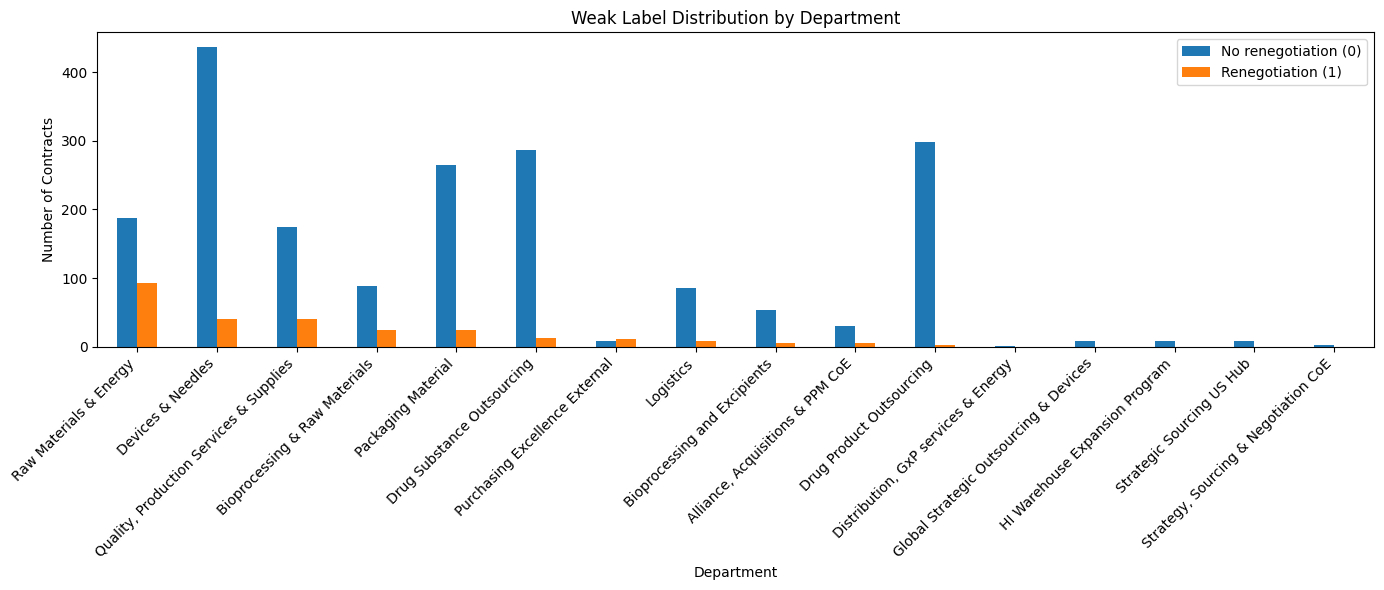

In [13]:
df_plot = (
    df_snorkel[["contract_id", "department", "target_renegotiate"]]
    .drop_duplicates(subset=["contract_id"])
    .copy()
)
df_plot["department"] = df_plot["department"].fillna("Unknown")

dept_counts = (
    df_plot.groupby(["department", "target_renegotiate"])
    .size()
    .unstack(fill_value=0)
)
for col in [0, 1]:
    if col not in dept_counts.columns:
        dept_counts[col] = 0
dept_counts = dept_counts[[0, 1]].sort_values(1, ascending=False)

ax = dept_counts.plot(kind="bar", figsize=(14, 6))
ax.set_title("Weak Label Distribution by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Number of Contracts")
ax.legend(["No renegotiation (0)", "Renegotiation (1)"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9  Save outputs

In [14]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

out_path = DATA_PROCESSED / "contract_snorkel_labeled.csv"
df_snorkel.to_csv(out_path, index=False)
print(f"Saved weak-labeled dataset → {out_path}")

tables_dir = REPORTS / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
lf_summary.to_csv(tables_dir / "snorkel_lf_summary.csv", index=False)
group_summary.to_csv(tables_dir / "snorkel_group_summary.csv", index=False)
print(f"Saved LF summaries → {tables_dir}")

Saved weak-labeled dataset → /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_snorkel_labeled.csv
Saved LF summaries → /Users/Thomas/Desktop/Master Thesis/reports/tables


---
## 10  Interpretation

